# Equilibrium Open Probability (Popen) and Dose–Response Curves

This notebook demonstrates `scalcs.popen` — calculation of the equilibrium open probability
for a kinetic mechanism, corrected for missed events (HJC theory).

**Topics covered**
1. Ideal (no missed-event correction) and HJC-corrected Popen at a single concentration  
2. Full Popen vs concentration curve  
3. `maxPopen`, EC50, Hill slope (nH)  
4. Non-monotonic Popen: fast pore blocker  
5. Note on a bug fixed in 2026-06-07 in `maxPopen`

**Reference mechanism:** Colquhoun & Hawkes 1982 (CH82) — 5-state agonist-gated channel.

**Time resolution:** tres = 50 µs throughout (except where noted).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math

from scalcs.samples import samples
from scalcs import popen as pop
from scalcs import scplotlib as scpl
from scalcs import qmatlib as qml

## 1. Load mechanism and set concentration

CH82 has two open states (A2R\* and AR\*), two shut states (A2R, AR) and one
closed state (R).  The two agonist-binding steps gate the channel open.

In [2]:
mec = samples.CH82()
tres = 50e-6   # 50 µs temporal resolution
conc = 100e-9  # 100 nM agonist

print(mec)


class dcpyps.Mechanism
Values of unit rates [1/sec]:
0	From AR  	to AR*    	beta1   	15.0
1	From A2R  	to A2R*    	beta2   	15000.0
2	From AR*  	to AR    	alpha1   	3000.0
3	From A2R*  	to A2R    	alpha2   	500.0
4	From AR  	to R    	k(-1)   	2000.0
5	From A2R  	to AR    	2k(-2)   	4000.0
6	From R  	to AR    	2k(+1)   	100000000.0
7	From AR*  	to A2R*    	k*(+2)   	500000000.0
8	From AR  	to A2R    	k(+2)   	500000000.0
9	From A2R*  	to AR*    	2k*(-2)   	0.66667

Conductance of state AR* (pS)  =      60

Conductance of state A2R* (pS)  =      60

Number of open states = 2
Number of short-lived shut states (within burst) = 2
Number of long-lived shut states (between bursts) = 1
Number of desensitised states = 0

Number of cycles = 1
Cycle 0 is formed of states: A2R*  AR*  AR  A2R  
	forward product = 1.500007500e+16
	backward product = 1.500000000e+16


## 2. Popen at a single concentration

Two paths:
- **tres = 0** — ideal Popen: equilibrium occupancy of open states (sum of open-state π∞)
- **tres > 0** — HJC-corrected Popen: accounts for undetected brief openings/closings

At low concentration the correction is small; at intermediate concentrations the HJC Popen
is lower than ideal because brief openings are missed, effectively reducing the apparent
mean open time.

In [3]:
p_ideal = pop.Popen(mec, tres=0,  conc=conc)
p_hjc   = pop.Popen(mec, tres=tres, conc=conc)

print(f"Concentration     : {conc*1e9:.0f} nM")
print(f"Ideal Popen       : {p_ideal:.6f}")
print(f"HJC Popen (tres={tres*1e6:.0f} µs): {p_hjc:.6f}")

# Cross-check: ideal Popen == sum(pinf over open states)
mec.set_eff('c', conc)
pinf = qml.pinf(mec.Q)
pinf_open = float(np.sum(pinf[:mec.kA]))
print(f"\nCross-check — sum(π∞ for open states): {pinf_open:.6f}")
print(f"Matches ideal Popen: {abs(pinf_open - p_ideal) < 1e-10}")

Concentration     : 100 nM
Ideal Popen       : 0.001887
HJC Popen (tres=50 µs): 0.001949

Cross-check — sum(π∞ for open states): 0.001887
Matches ideal Popen: True


## 3. Popen versus concentration (dose–response curve)

`scplotlib.Popen` returns arrays of concentrations and Popen values for the ideal and
HJC-corrected curves.

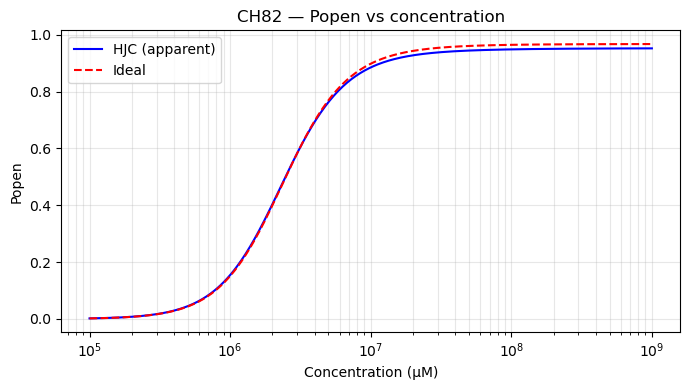

In [4]:
c_arr, p_e, p_i = scpl.Popen(mec, tres)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(c_arr * 1e6, p_e, 'b-',  label='HJC (apparent)')
ax.semilogx(c_arr * 1e6, p_i, 'r--', label='Ideal')
ax.set_xlabel('Concentration (µM)')
ax.set_ylabel('Popen')
ax.set_title('CH82 — Popen vs concentration')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()

## 4. maxPopen, EC50 and Hill slope

These three scalars summarise the dose–response curve:

| Quantity | Meaning |
|----------|---------|
| `maxPopen` | Asymptotic open probability at saturating agonist |
| `EC50` | Concentration at which Popen = 50% of (maxPopen − Popen₀) |
| `nH` | Hill slope at EC50 (steepness of dose–response) |

In [5]:
# Ideal (tres=0)
maxP_i, cmax_i = pop.maxPopen(mec, tres=0)
ec50_i  = pop.EC50(mec, tres=0)
nH_i    = pop.nH(mec, tres=0)

# HJC-corrected
maxP_e, cmax_e = pop.maxPopen(mec, tres=tres)
ec50_e  = pop.EC50(mec, tres=tres)
nH_e    = pop.nH(mec, tres=tres)

print("=== Ideal (tres = 0) ===")
print(f"  maxPopen : {maxP_i:.5f}  at {cmax_i*1e6:.2f} µM")
print(f"  EC50     : {ec50_i*1e6:.3f} µM")
print(f"  nH       : {nH_i:.3f}")

print(f"\n=== HJC-corrected (tres = {tres*1e6:.0f} µs) ===")
print(f"  maxPopen : {maxP_e:.5f}  at {cmax_e*1e6:.2f} µM")
print(f"  EC50     : {ec50_e*1e6:.3f} µM")
print(f"  nH       : {nH_e:.3f}")

=== Ideal (tres = 0) ===
  maxPopen : 0.96774  at 316227.77 µM
  EC50     : 2.403 µM
  nH       : 1.892

=== HJC-corrected (tres = 50 µs) ===
  maxPopen : 0.95268  at 316227.77 µM
  EC50     : 2.347 µM
  nH       : 1.889


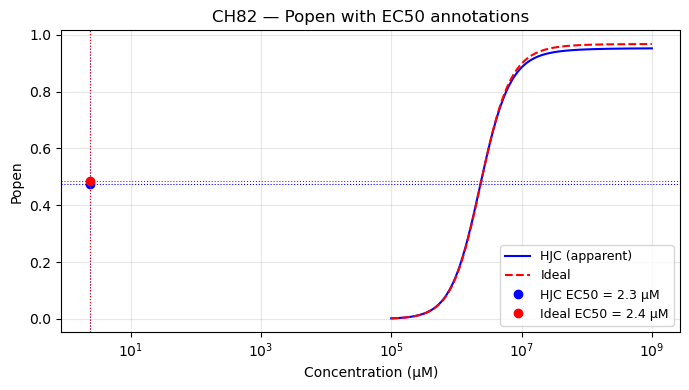

In [6]:
# Annotate the EC50 on the dose-response plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(c_arr * 1e6, p_e, 'b-',  label='HJC (apparent)')
ax.semilogx(c_arr * 1e6, p_i, 'r--', label='Ideal')

for ec50, maxP, color, label in [
        (ec50_e, maxP_e, 'b', 'HJC EC50'),
        (ec50_i, maxP_i, 'r', 'Ideal EC50')]:
    ax.axvline(ec50 * 1e6, color=color, lw=0.8, ls=':')
    ax.axhline(maxP / 2,   color=color, lw=0.8, ls=':')
    ax.plot(ec50 * 1e6, maxP / 2, 'o', color=color, ms=6,
            label=f'{label} = {ec50*1e6:.1f} µM')

ax.set_xlabel('Concentration (µM)')
ax.set_ylabel('Popen')
ax.set_title('CH82 — Popen with EC50 annotations')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()

## 5. printout — concise summary table

`popen.printout` replicates the text output of the original DCPROGS Fortran program.

In [7]:
print(pop.printout(mec, tres))


*******************************************
Popen CURVE

HJC Popen curve:
maxPopen = 0.95268;  EC50 = 2.3467 microM;  nH = 1.8894
Ideal Popen curve:
maxPopen = 0.96774;  EC50 = 2.4032 microM;  nH = 1.892


## 6. Non-monotonic Popen — fast pore blocker

When a fast pore blocker is present, `Popen` is corrected by a factor
$1 / (1 + c / K_B)$.  At high concentrations the blocker wins and Popen
decreases — producing a **non-monotonic** curve with a clear maximum.

Setting `mec.fastKB = KB` enables this correction automatically inside
every `popen.*` function call.  `maxPopen` locates the peak via a two-phase
algorithm:

1. **Outer search loop** — steps in √10 increments from 1 nM, detects when
   the curve stops rising (sign change in the relative change of Popen).
2. **Inner bisection** — narrows the bracket to `epsc = c1 / 1000` precision.

> **Bug fixed 2026-06-07 (commit `modernise` branch):** The original inner
> bisection contained five errors (wrong evaluation concentrations, overwritten
> variable, backwards bracket updates, missing `nstep` increment, wrong
> convergence criterion).  Net effect: the loop exited after one trivial step
> returning an inaccurate peak location for any non-monotonic curve.  Plain
> monotonic mechanisms were unaffected because the bisection branch was never
> entered.

In [8]:
mec_blk = samples.CH82()
KB = 1e-3   # 1 mM fast-blocker dissociation constant
mec_blk.fastKB = KB
print(f"Fast blocker enabled: {mec_blk.fastblock}")
print(f"KB = {mec_blk.fastKB * 1e3:.1f} mM")

Fast blocker enabled: True
KB = 1.0 mM


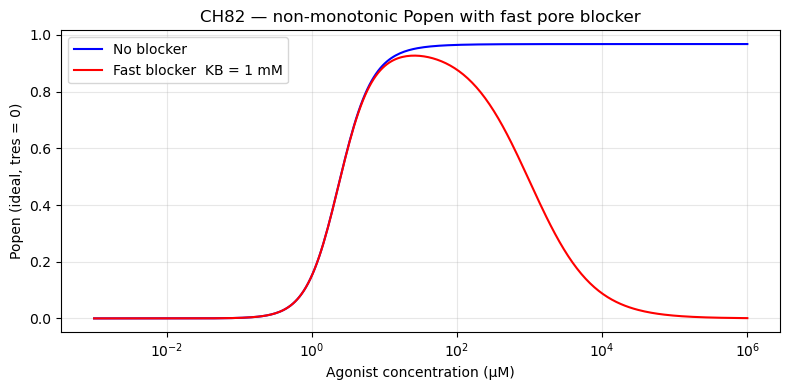

In [9]:
# Build the dose–response curve manually for the blocked mechanism
c_scan = np.logspace(-9, 0, 300)   # 1 nM → 1 M
p_blk = np.array([pop.Popen(mec_blk, tres=0, conc=c) for c in c_scan])
p_unblk = np.array([pop.Popen(mec, tres=0, conc=c) for c in c_scan])

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(c_scan * 1e6, p_unblk, 'b-',  lw=1.5, label='No blocker')
ax.semilogx(c_scan * 1e6, p_blk,   'r-',  lw=1.5, label=f'Fast blocker  KB = {KB*1e3:.0f} mM')

ax.set_xlabel('Agonist concentration (µM)')
ax.set_ylabel('Popen (ideal, tres = 0)')
ax.set_title('CH82 — non-monotonic Popen with fast pore blocker')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()

In [10]:
# Locate and annotate the peak using maxPopen
maxP_blk, cmax_blk = pop.maxPopen(mec_blk, tres=0)
print(f"maxPopen (blocked) : {maxP_blk:.5f}")
print(f"cmax               : {cmax_blk * 1e6:.3f} µM")

# Verify: dense scan maximum matches maxPopen to within 2%
scan_max = float(p_blk.max())
print(f"Scan max           : {scan_max:.5f}  (at {float(c_scan[p_blk.argmax()]*1e6):.3f} µM)")
print(f"Relative error     : {abs(maxP_blk - scan_max)/scan_max * 100:.2f}%")

maxPopen (blocked) : 0.92574
cmax               : 31.631 µM
Scan max           : 0.92692  (at 26.592 µM)
Relative error     : 0.13%


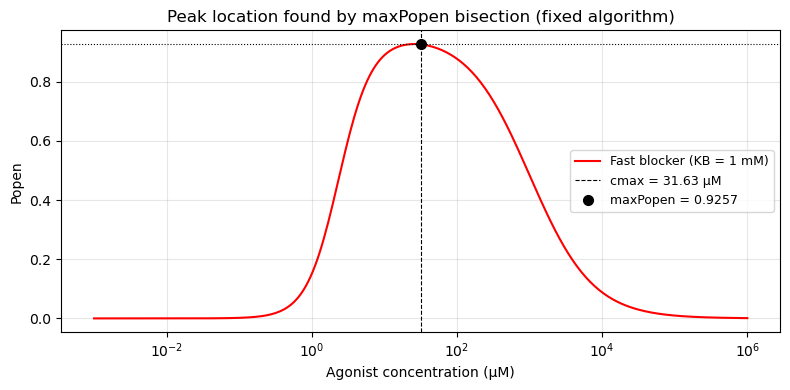

In [11]:
# Annotated plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(c_scan * 1e6, p_blk, 'r-', lw=1.5, label=f'Fast blocker (KB = {KB*1e3:.0f} mM)')
ax.axvline(cmax_blk * 1e6, color='k', lw=0.8, ls='--', label=f'cmax = {cmax_blk*1e6:.2f} µM')
ax.axhline(maxP_blk,       color='k', lw=0.8, ls=':')
ax.plot(cmax_blk * 1e6, maxP_blk, 'ko', ms=7,
        label=f'maxPopen = {maxP_blk:.4f}')

ax.set_xlabel('Agonist concentration (µM)')
ax.set_ylabel('Popen')
ax.set_title('Peak location found by maxPopen bisection (fixed algorithm)')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()

## 7. Summary of the maxPopen bug fix

The original code (pre 2026-06-07) in `scalcs/popen.py` lines 109–119:

```python
# BUGGY — do not use
while nstep <= maxnstep and math.fabs(perr) > 0:
    conc = 0.5 * (c1 + c2)
    conc1 = conc / fac          # ① sets conc1 = conc/1.01
    P1 = Popen(mec, tres, conc) # ② BUG: evaluates at conc, not conc1
    conc1 = conc * fac          # ③ BUG: overwrites conc1; loses conc/fac
    P2 = Popen(mec, tres, conc) # ④ BUG: evaluates at conc again
    perr = P2 - P1              #    → always 0 (P1 == P2)
    if perr < 0:
        c1 = conc1              # ⑤ BUG: bracket update backwards
    else:
        c2 = conc1              # ⑤ BUG: bracket update backwards
                                # ⑥ BUG: nstep never incremented
```

Because P1 == P2, `perr = 0` after the first iteration and the loop exited
immediately with no real bisection done.

**Fixed code:**

```python
while nstep <= maxnstep and (c2 - c1) > epsc:
    conc = 0.5 * (c1 + c2)
    conc1 = conc / fac          # slightly below midpoint
    conc2 = conc * fac          # slightly above midpoint
    P1 = Popen(mec, tres, conc1)
    P2 = Popen(mec, tres, conc2)
    perr = P2 - P1
    if perr > 0:    # curve still rising → max to the right
        c1 = conc
    else:           # curve falling → max to the left
        c2 = conc
    nstep += 1
conc = 0.5 * (c1 + c2)         # best estimate: final bracket midpoint
```

**Impact on published results:** The bug only affected mechanisms with a
non-monotonic Popen curve (e.g. with a pore blocker or an inhibitory site).
Standard agonist-gated mechanisms (monotonic Popen) were never affected
because the bisection branch was dead code for those.